# Amazon Reviews MapReduce EDA
This notebook loads MapReduce outputs, joins product metadata, and generates summary visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
METADATA_FILE = 'data/meta_software.jsonl'
AVG_FILE = 'results/avg_ratings.csv'
REVIEWS_FILE = 'results/review_counts.csv'
HELPFULNESS_FILE = 'results/helpfulness.csv'
SENTIMENT_FILE = 'results/sentiment.csv'
TOP_TEN_FILE = 'results/top_ten.csv'


## Load metadata

In [3]:
meta = pd.read_json(METADATA_FILE, lines=True)
meta.columns = [c.lower() for c in meta.columns]
meta['parent_asin'] = meta['parent_asin'].astype(str).str.upper()
meta_subset = meta[['parent_asin','title']].drop_duplicates('parent_asin')

meta_subset.head()

,parent_asin,title
0,B00VRPSGEO,Accupressure Guide
1,B00NWQXXHQ,Ankylosaurus Fights Back - Smithsonian's Prehi...
2,B00RFKP6AC,Mahjong 2015
3,B00SP2QU0E,Jewels Brick Breakout
4,B01DZIT64O,Traffic Police: Off-Road Cub


## Average ratings

In [4]:
avg = pd.read_csv(AVG_FILE, header=None, names=['asin','avg_rating'], sep=",")
avg['asin'] = avg['asin'].astype(str).str.upper()

avg_named = avg.merge(meta_subset, left_on='asin', right_on='parent_asin', how='left')
avg_named = avg_named[['asin','title','avg_rating']]

avg_named.sort_values('avg_rating', ascending=False).head()


,asin,title,avg_rating
4,72119527,NaN,5.0
90354,B0C3Z6XS3L,Tech-Shop-pro Compatible Windows 10 Profession...,5.0
0,5162092,NaN,5.0
6,007742817X,Instructor's Resource CD-ROM for The Art of Sp...,5.0
7,77431618,NaN,5.0


### Average rating distribution 

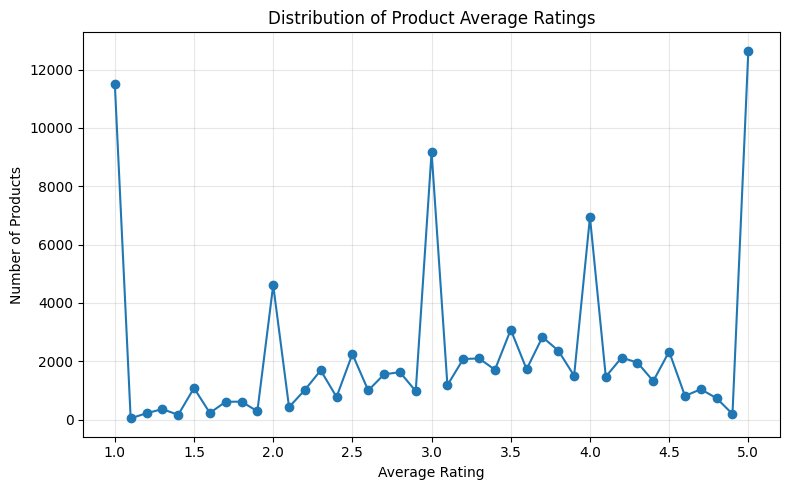

In [5]:
rating_dist = (
    avg_named["avg_rating"]
    .round(1)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.plot(
    rating_dist.index,
    rating_dist.values,
    marker="o"
)

plt.xlabel("Average Rating")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Average Ratings")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("media/avg-rating-distribution.png")

plt.show()

## Review counts

In [6]:
reviews = pd.read_csv(REVIEWS_FILE, header=None, names=['asin','review_count'], sep="\t")

reviews['asin'] = reviews['asin'].astype(str).str.replace('"','').str.upper()

reviews_named = reviews.merge(meta_subset, left_on='asin', right_on='parent_asin', how='left')
reviews_named[['asin','title','review_count']].head()


,asin,title,review_count
0,0005162092,Hebrew Tutor-Windows,2
1,0028217012,American History Primary Source Document Library,1
2,0030369371,Calculus: Preparation for the Calculus AB and ...,1
3,0071480935,"Sing, Watch, & Learn Spanish (DVD + Guide): 16...",4
4,0072119527,A+ Certification Test Yourself Personal Testin...,1


## Top ten products

In [7]:

top10 = pd.read_csv(TOP_TEN_FILE, header=None, names=['asin','review_count'], sep="\t")

top10['asin'] = top10['asin'].astype(str).str.replace('"','').str.upper()

top10_named = top10.merge(meta_subset, left_on='asin', right_on='parent_asin', how='left')
top10_named = top10_named[['asin','title','review_count']]
top10_named


,asin,title,review_count
0,B017POZ7Y2,Scatter Slots - Play The Best Free 777 Casino ...,1
1,B0C9V8PZNY,Surfshark VPN : Protect your digital life | 1 ...,1
2,B0C9FYN8GF,NaN,1
3,B0C46GX5J4,Video and Audio Downloader PRO 2 software for ...,1
4,B0C3Z6XS3L,Tech-Shop-pro Compatible Windows 10 Profession...,2
5,B0C39R1GZR,Humanoid Huntress,1
6,B0C365SFSW,Tech-Shop-pro Compatible Windows 10 Home and p...,2
7,B0C2J7MB9G,Monster Catching: Exciting Merge & Combat Adve...,1
8,B0C2J7CMZC,Idle Waterpark - Water Slide Tycoon,1
9,B0C1SCHKLQ,"TalkGPT: AI Voice Chat, AI Bot",2


## Helpfulness score

In [8]:
helpfulness = pd.read_csv(HELPFULNESS_FILE, sep='\t', header=None)
helpfulness


,0,1
0,ave_helpful_score,0.425703


## Sentiment distribution

In [9]:
sent = pd.read_csv(SENTIMENT_FILE, sep='\t', header=None, names=['sentiment','count'])

sent['sentiment'] = sent['sentiment'].astype(str).str.replace('"','')

sent


,sentiment,count
0,negative,673485
1,neutral,516329
2,positive,3630398


### Plot sentiment distribution

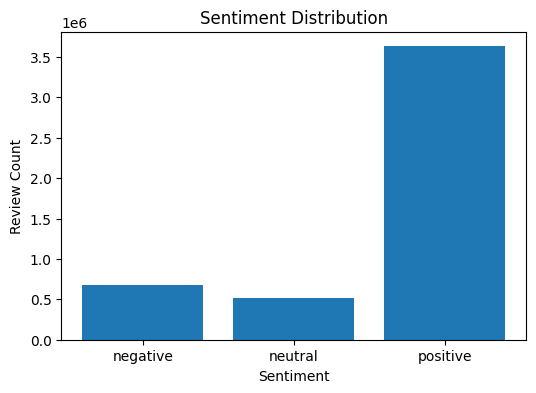

In [10]:
plt.figure(figsize=(6,4))
plt.bar(sent['sentiment'], sent['count'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Review Count')
plt.savefig("media/sentiment-distribution.png")
plt.show()


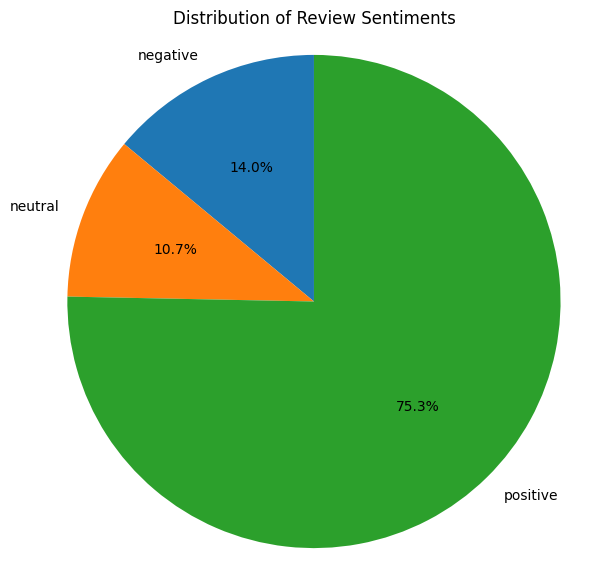

In [11]:
plt.figure(figsize=(7, 7))

plt.pie(
    sent["count"],
    labels=sent["sentiment"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Review Sentiments")
plt.axis("equal") 

plt.savefig("media/pie-sentiment.png")
plt.show()

## Plot top products by review count

/tmp/ipykernel_94781/1888675201.py:7: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


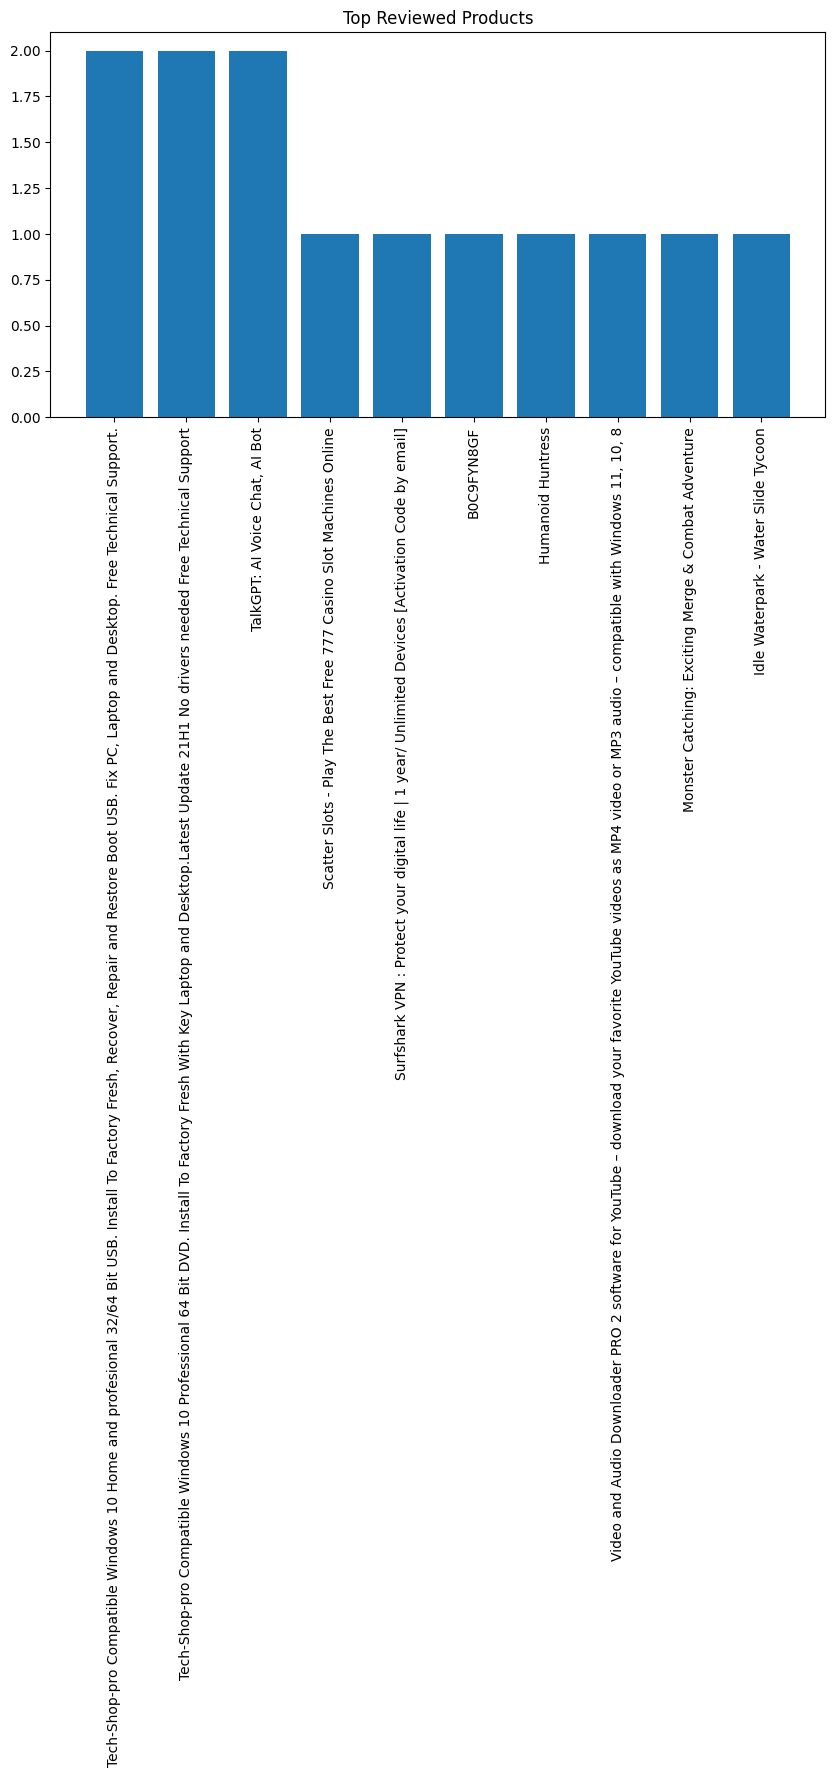

In [12]:
top10_named = top10_named.sort_values('review_count', ascending=False)

plt.figure(figsize=(10,5))
plt.bar(range(len(top10_named)), top10_named['review_count'])
plt.xticks(range(len(top10_named)), top10_named['title'].fillna(top10_named['asin']), rotation=90)
plt.title('Top Reviewed Products')
plt.tight_layout()
plt.savefig("media/top-10-reviewed-products.png")
plt.show()
